In [15]:
pip install torchmetrics

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 4.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchmetrics] [torchmetrics]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
from livelossplot import PlotLosses 
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
                                RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
                                ToTensor, Compose, NormalizeIntensity, Lambda)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

import numpy as np

import os

from PIL import Image

import random

import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

import time

import torch
from torch.utils.data import Dataset
from torchvision.models import efficientnet_b7
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score


np.random.seed(0)
set_determinism(seed=0)
print_config()

MONAI version: 1.5.2
Numpy version: 2.2.6
Pytorch version: 2.12.0+cu130
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /mounts/<username>/.local/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.15.3
Pillow version: 12.0.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.27.0+cu130
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.0.0
pandas version: 2.3.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT IN

In [3]:
model_name = './models/efficientnet_b7.pth'

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [20]:
#Carregar o nosso dataset e perceber a distribuição de classes

base_dir = './dataset'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
#class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
                            os.path.join(class_dir, x)
                            for x in os.listdir(class_dir)
                            if x.lower().endswith(valid_exts)
                        ]

        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))
    

Train count = 1067
Val count = 234
Test count = 267


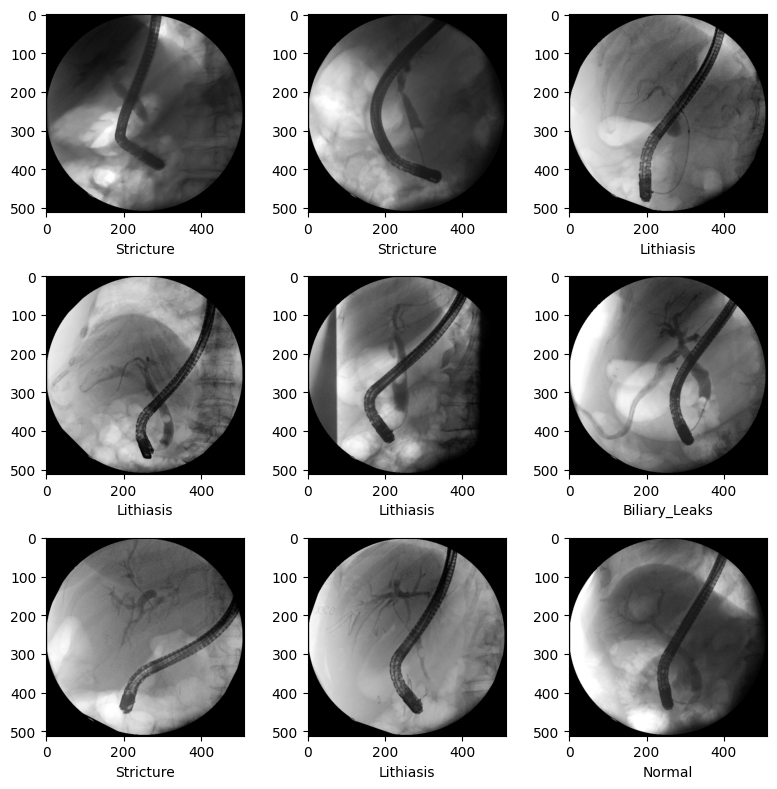

In [6]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()


----- TRAIN CASES -----
cases: 1067
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[110 505 197 255]
1067


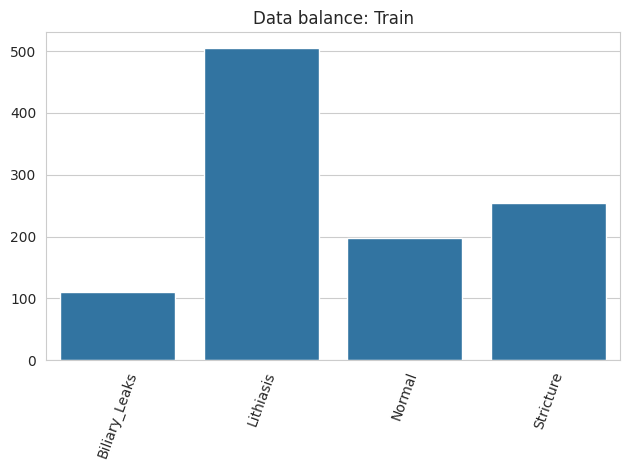

----- VALIDATION CASES -----
cases: 234
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[24 98 59 53]
234


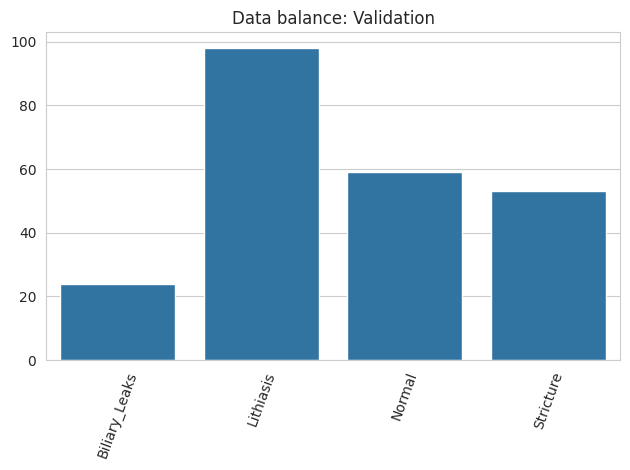

----- TEST CASES -----
cases: 267
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 17 123  43  84]
267


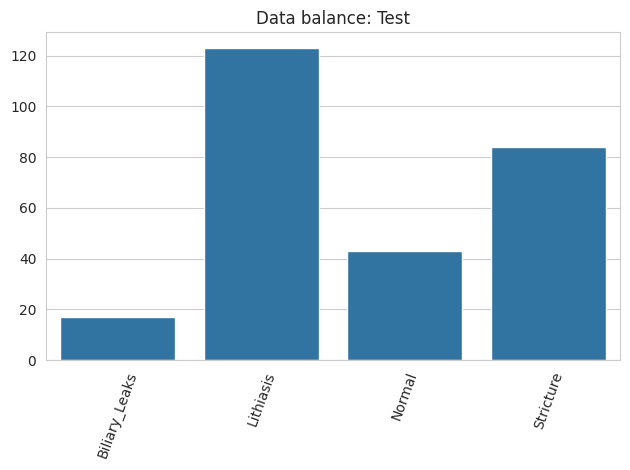

In [7]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext=[class_names[n]  for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico=sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("----- VALIDATION CASES -----")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("----- TEST CASES -----")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')


In [8]:
class EnsureSingleChannel:
    def __call__(self, img):
        if img.shape[0] == 3:
            img = img.mean(dim=0, keepdim=True)
        return img

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img
    
train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    RandRotate(range_x=15, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

In [22]:
# Dataset e DataLoaders
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image = self.image_files[index]
        return self.transforms(image), self.labels[index]

train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)

val_ds = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
val_loader = DataLoader(val_ds, batch_size=4, num_workers=0)

test_ds = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)
test_loader = DataLoader(test_ds, batch_size=4, num_workers=0)

In [10]:
#Instanciar uma EffiecientNet prétreinada e adaptar os cabeçalhos com o nº de classes

device = torch.device("cuda:0")
model = efficientnet_b7(pretrained=True) 
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class) 
model = model.to(device)

/mounts/mecd-ap-g6/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mounts/mecd-ap-g6/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B7_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B7_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.device_count())

2.12.0+cu130
True
13.0
1


In [11]:
#TREINO 

def train_model(train_dl, val_dl, model, loss_function, optimizer, epochs, name):
    early_stopping_patience = 10
    epochs_without_improvement = 0
    liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f"{name}.png")])
    best_metric = -1
    best_metric_epoch = -1
    metric_values = list()

    # F1 metric
    f1_metric = MulticlassF1Score(num_classes=num_class, average='macro').to(device)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) 

    for epoch in range(epochs):
        logs = {}
        model.train()
        epoch_loss = 0
        running_loss = 0.0
        running_corrects = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train = torch.tensor([], dtype=torch.long, device=device)

        for inputs, labels in train_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            #outputs = torch.softmax(outputs, dim=1)
            loss = loss_function(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.detach() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train = torch.cat([y_pred_train, outputs], dim=0)
            y_train = torch.cat([y_train, labels], dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc = running_corrects.float() / len(train_dl.dataset)

        # Compute F1-score on training set
        pred_train_labels = y_pred_train.argmax(dim=1)
        f1_train_value = f1_metric(pred_train_labels, y_train)

        logs['loss'] = epoch_loss.item()
        logs['accuracy'] = epoch_acc.item()
        logs['F1'] = f1_train_value.item()  # Train F1

        # Validation phase
        model.eval()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y = torch.tensor([], dtype=torch.long, device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)
                outputs = model(val_images)
                #outputs = torch.softmax(outputs, dim=1)
                loss = loss_function(outputs, val_labels)
                running_loss += loss.detach() * val_images.size(0)
                _, preds = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y = torch.cat([y, val_labels], dim=0)

            epoch_loss = running_loss / len(val_dl.dataset)
            epoch_acc = running_corrects.float() / len(val_dl.dataset)
            logs['val_loss'] = epoch_loss.item()
            logs['val_accuracy'] = epoch_acc.item()

            # Compute F1-score on validation set
            pred_labels = y_pred.argmax(dim=1)
            f1_score_value = f1_metric(pred_labels, y)
            logs['val_F1'] = f1_score_value.item()

            y_onehot = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [act(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)

            if f1_score_value > best_metric:
                best_metric = f1_score_value
                best_metric_epoch = epoch + 1
                best_train_f1 = f1_train_value.item()   
                torch.save(model.state_dict(), name)
                print('saved new best metric model')
                epochs_without_improvement = 0  # reset counter
            else:
                epochs_without_improvement += 1
            
            if epochs_without_improvement >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch + 1} \n"
                    f" Best Val F1: {best_metric:.4f} \n"
                    f" Best Train F1: {best_train_f1:.4f} \n"
                    f" current Val F1: {f1_score_value:.4f} \n"
                    f" current Train F1: {f1_train_value:.4f} \n"
                    f" Best epoch: {best_metric_epoch} \n"
                )
                break
            print(
                f"current epoch: {epoch + 1} current AUC: {result:.4f}"
                f" current F1 (train): {f1_train_value:.4f}"
                f" current F1 (val): {f1_score_value:.4f}"
                f" best AUC: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )
        
        logs['val_AUC'] = result
        liveloss.update(logs)
        liveloss.send()

        scheduler.step() 

    print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")


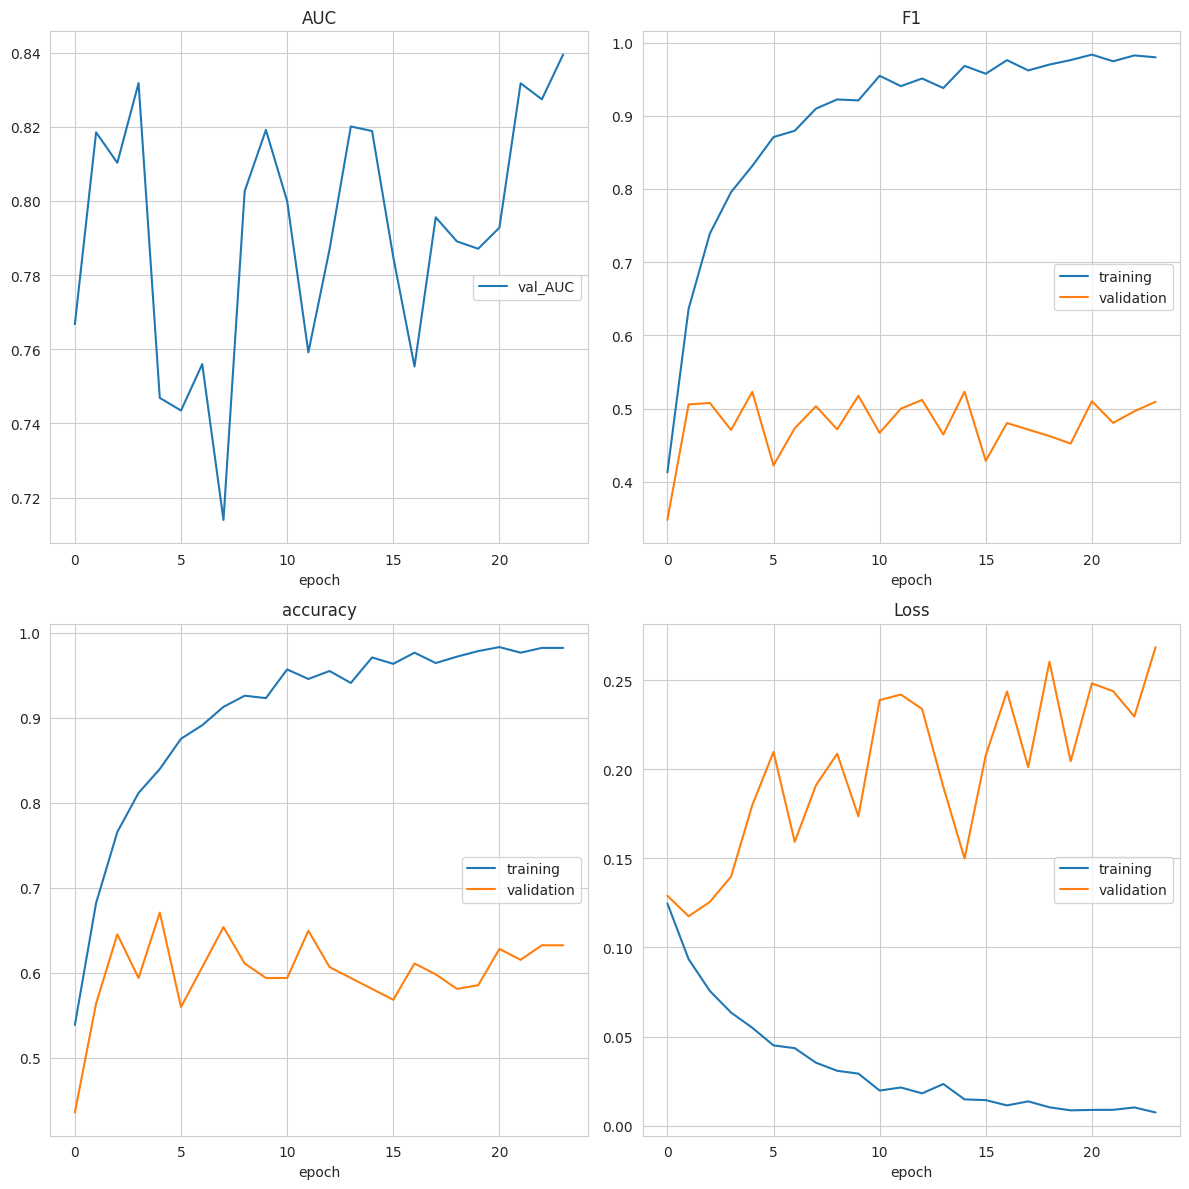

Early stopping at epoch 25 
 Best Val F1: 0.5230 
 Best Train F1: 0.9681 
 current Val F1: 0.5053 
 current Train F1: 0.9821 
 Best epoch: 15 

train completed, best_metric: 0.5230 at epoch: 15
Time elapsed: 2198.7528633280017 seconds


In [12]:
EPOCHS = 60
LEARNING_RATE = 1e-4

from monai.losses import FocalLoss
loss_function = FocalLoss(to_onehot_y=True)

optimizer = torch.optim.Adam(model.parameters(), LEARNING_RATE)

val_interval = 1
auc_metric = ROCAUCMetric()

device = torch.device("cuda")
starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS, model_name)
endtime = time.perf_counter()
print(f"Time elapsed: {endtime - starttime} seconds")

F1 Score: 0.6721
true: [0] pred: [0]
true: [0] pred: [1]
true: [0] pred: [1]
true: [0] pred: [0]
true: [0] pred: [0]
true: [0] pred: [2]
true: [0] pred: [0]
true: [0] pred: [2]
true: [0] pred: [0]
true: [0] pred: [2]
true: [0] pred: [2]
Accuracy: 0.715

correct: 5 incorrect: 6
Accuracy: 0.715

correct: 5 incorrect: 6
F1 Score: 0.6721
               precision    recall  f1-score   support

Biliary_Leaks     0.6000    0.5294    0.5625        17
    Lithiasis     0.7339    0.7398    0.7368       123
       Normal     0.5800    0.6744    0.6237        43
    Stricture     0.7949    0.7381    0.7654        84

     accuracy                         0.7154       267
    macro avg     0.6772    0.6704    0.6721       267
 weighted avg     0.7198    0.7154    0.7165       267

[[ 9  2  6  0]
 [ 5 91 13 14]
 [ 1 11 29  2]
 [ 0 20  2 62]]


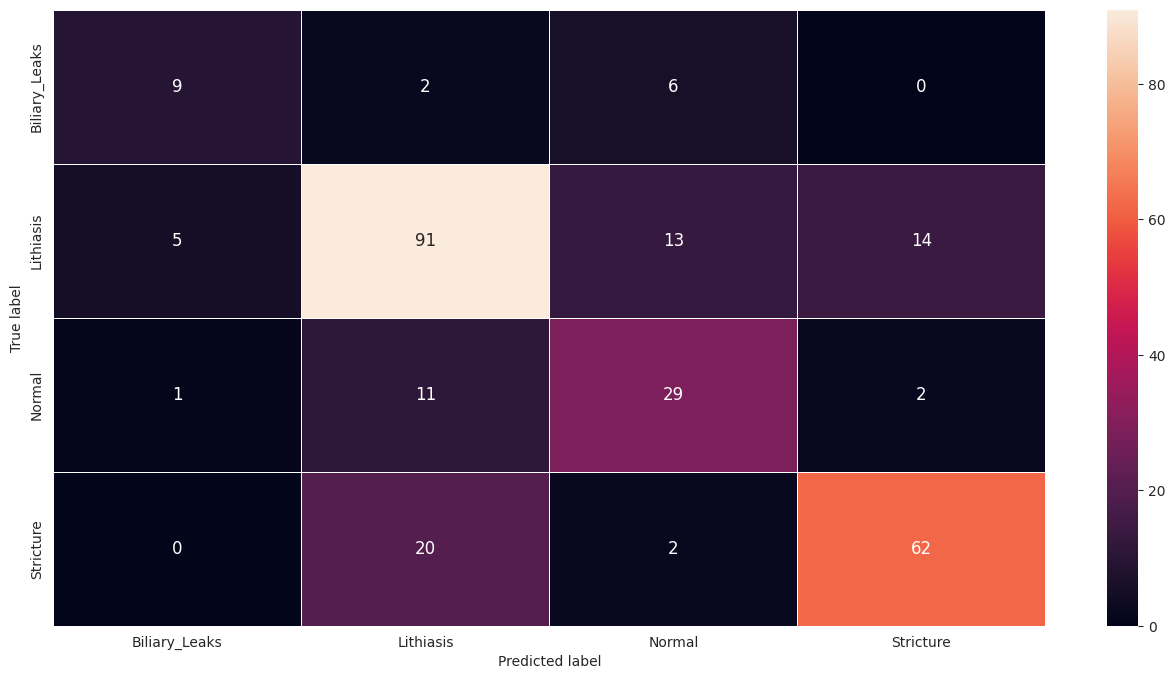

In [14]:
def evaluate_model(test_dl, model):
    predictions = list()
    actual_values = list()
    for inputs, labels in test_dl:
        # evaluate the model on the test set
        inputs = inputs.to(device)
        labels = labels.to(device)
        yprev = model(inputs)
        yprev = yprev.detach().cpu().numpy()
        actual = labels.cpu().numpy()
        yprev = np.argmax(yprev, axis=1)
        actual = actual.reshape((len(actual), 1))
        yprev = yprev.reshape((len(yprev), 1))
        predictions.append(yprev)
        actual_values.append(actual)
    predictions, actual_values = np.vstack(predictions), np.vstack(actual_values)
    
    # Compute F1-score
    f1 = f1_score(actual_values, predictions, average='macro')  # Can be 'micro', 'macro' or 'weighted'
    print(f"F1 Score: {f1:0.4f}")
    
    return actual_values, predictions

def display_predictions(actual_values, predictions):
    right = 0
    wrong = 0
    primeiros = 0
    i = 0
    for r, p in zip(actual_values, predictions):
        if primeiros < 20:
            print(f'true: {r} pred: {p}')
            primeiros += 1
        if r == p:
            right += 1
        else:
            wrong += 1
        i += 1
        if i > 10:
            break

    # Compute accuracy
    corrects = np.sum(predictions == actual_values)
    acc = corrects / len(test_loader.dataset)
    acc = accuracy_score(actual_values, predictions)
    print(f'Accuracy: {acc:0.3f}\n')
    print(f'correct: {right} incorrect: {wrong}')
    acc = accuracy_score(actual_values, predictions)
    print(f'Accuracy: {acc:0.3f}\n')
    print(f'correct: {right} incorrect: {wrong}')

    # Compute F1-score
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f"F1 Score: {f1:0.4f}")

def display_confusion_matrix(cm, list_classes, filename):
    plt.figure(figsize=(16, 8))
    sns.heatmap(cm, annot=True, xticklabels=list_classes, yticklabels=list_classes, annot_kws={"size": 12}, fmt='g', linewidths=.5)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(f"{filename}_cm.png", dpi=300)
    plt.show()

# Load trained model
model.load_state_dict(torch.load('./' + model_name))
model.eval()

# Evaluate the model
actual_values, predictions = evaluate_model(test_loader, model)

# Display the predictions
display_predictions(actual_values, predictions)

# Classification report
print(classification_report(actual_values, predictions, target_names=class_names, digits=4, zero_division=0))

# Confusion Matrix
cr = classification_report(actual_values, predictions, target_names=class_names, output_dict=True)
list_classes = [cls for cls in cr.keys() if cls in class_names]

cm = confusion_matrix(actual_values, predictions)

print(cm)
display_confusion_matrix(cm, list_classes, model_name)

In [15]:
#Melhorias face ao que já estava

In [16]:
import torch
import torch.nn as nn
from torchvision import models

# RESOLUÇÃO DO ERRO: Garantir que o dispositivo está definido nesta célula
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo configurado com sucesso: {device}")

print("A carregar a EfficientNet-B4 (SOTA)...")
# 1. Carregar a EfficientNet-B4 pré-treinada
modelo_sota = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)

# 2. CONGELAR todas as camadas iniciais (Feature Extraction)
# Isto impede o modelo de sofrer overfitting imediato!
for param in modelo_sota.parameters():
    param.requires_grad = False

# 3. Substituir o classificador final para as nossas 4 classes
# Na EfficientNet, a última camada chama-se 'classifier'
num_ftrs = modelo_sota.classifier[1].in_features
modelo_sota.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True), # Dropout adiciona robustez contra overfitting
    nn.Linear(num_ftrs, 4)
)

modelo_sota = modelo_sota.to(device)

# 4. Otimizador focado APENAS nas camadas que estão descongeladas (o classificador)
# Usamos AdamW que já inclui uma ótima regularização por defeito
otimizador_sota = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, modelo_sota.parameters()), 
    lr=1e-3, 
    weight_decay=1e-2
)

# Configurar a nossa Focal Loss passando os pesos calculados para o 'alpha'
pesos_tensor = torch.tensor([1.3541, 2.4250, 0.5282, 1.0461], dtype=torch.float32).to(device)
criterio_focal = FocalLoss(alpha=pesos_tensor, gamma=2)

print("EfficientNet-B4 configurada com camadas iniciais congeladas!")

Dispositivo configurado com sucesso: cuda:0
A carregar a EfficientNet-B4 (SOTA)...
EfficientNet-B4 configurada com camadas iniciais congeladas!


In [24]:
import torch
import torch.nn as nn
import time
import copy
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.models as models

# Importações das transformações da MONAI que a Mónica usou
from monai.transforms import (Compose, LoadImage, EnsureChannelFirst, Resize,
                               RandRotate, RandZoom, RandAdjustContrast, RandGaussianNoise,
                               NormalizeIntensity, Lambda, ToTensor)
from monai.losses import FocalLoss

# ========================================================
# 1. CONFIGURAÇÃO DO AMBIENTE E HARDWARE
# ========================================================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
num_class = 4 
BATCH_SIZE = 4

print(f"Dispositivo: {device} | Batch Size: {BATCH_SIZE}")

# ========================================================
# 2. DEFINIÇÃO DO TEU DATASET (MedNISTDataset)[cite: 1]
# ========================================================
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image = self.image_files[index]
        return self.transforms(image), self.labels[index]

# ========================================================
# 3. TRANSFORMAÇÕES AVANÇADAS DA BASELINE (512x512)[cite: 1]
# ========================================================
def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

train_transforms_avancadas = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    RandRotate(range_x=15, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms_avancadas = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

# ========================================================
# 4. RECONSTRUÇÃO CORRETA DOS DATALOADERS[cite: 1]
# ========================================================
print("A carregar os datasets usando MedNISTDataset...")
# Usamos os caminhos exatos do teu dicionário 'data'[cite: 1]
dataset_treino = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms_avancadas)
dataset_val = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms_avancadas)

dataloader_treino = DataLoader(dataset_treino, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
dataloader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

dataloaders_avancados = {'treino': dataloader_treino, 'val': dataloader_val}

# ========================================================
# 5. CONFIGURAÇÃO DA FOCAL LOSS (DA MONAI)[cite: 1]
# ========================================================
criterio_focal = FocalLoss(to_onehot_y=True)

# ========================================================
# 6. CONFIGURAÇÃO DA EFFICIENTNET-B4 (SOTA CONGELADA)
# ========================================================
print("A inicializar a EfficientNet-B4 pré-treinada...")
modelo_sota = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)

# Congelar o corpo do modelo para evitar Overfitting imediato
for param in modelo_sota.parameters():
    param.requires_grad = False

# Mudar o classificador final para as nossas 4 classes
num_ftrs = modelo_sota.classifier[1].in_features
modelo_sota.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(num_ftrs, num_class)
)
modelo_sota = modelo_sota.to(device)

# Otimizador calibrado apenas para a camada final ativa
LEARNING_RATE = 1e-3
otimizador_sota = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, modelo_sota.parameters()), 
    lr=LEARNING_RATE, 
    weight_decay=1e-2
)

EPOCHS_CONGELADO = 5
scheduler_sota = CosineAnnealingLR(otimizador_sota, T_max=EPOCHS_CONGELADO)

# ========================================================
# 7. DEFINIÇÃO DO LOOP DE TREINO AVANÇADO
# ========================================================
def treinar_modelo_avancado(modelo, dataloaders, criterio, otimizador, scheduler, num_epocas=60, patience=10):
    tempo_inicio = time.time()
    melhor_modelo_pesos = copy.deepcopy(modelo.state_dict())
    melhor_loss = float('inf') 
    epocas_sem_melhoria = 0
    
    for epoca in range(num_epocas):
        print(f'\nÉpoca {epoca+1}/{num_epocas}')
        print('-' * 10)

        for fase in ['treino', 'val']:
            if fase == 'treino':
                modelo.train()
            else:
                modelo.eval()

            loss_acumulada = 0.0
            acertos_acumulados = 0

            loop = tqdm(dataloaders[fase], total=len(dataloaders[fase]), leave=False, desc=fase.capitalize())
            
            for imagens, labels in loop:
                imagens = imagens.to(device)
                labels = labels.to(device)

                otimizador.zero_grad()

                with torch.set_grad_enabled(fase == 'treino'):
                    saidas = modelo(imagens)
                    _, previsoes = torch.max(saidas, 1)
                    loss = criterio(saidas, labels)

                    if fase == 'treino':
                        loss.backward()
                        otimizador.step()

                loss_acumulada += loss.item() * imagens.size(0)
                acertos_acumulados += torch.sum(previsoes == labels.data)
                loop.set_postfix(loss=loss.item())

            epoca_loss = loss_acumulada / len(dataloaders[fase].dataset)
            epoca_acc = acertos_acumulados.double() / len(dataloaders[fase].dataset)

            print(f'{fase.capitalize()} Loss: {epoca_loss:.4f} Acc: {epoca_acc:.4f}')

            if fase == 'val':
                if epoca_loss < melhor_loss:
                    melhor_loss = epoca_loss
                    melhor_modelo_pesos = copy.deepcopy(modelo.state_dict())
                    epocas_sem_melhoria = 0
                    print(f"** Novo melhor modelo guardado! (Loss: {melhor_loss:.4f}) **")
                else:
                    epocas_sem_melhoria += 1
                    
        scheduler.step()
        
        if epocas_sem_melhoria >= patience:
            print(f"\n[Early Stopping] Paragem antecipada!")
            break

    tempo_decorrido = time.time() - tempo_inicio
    print(f'\nTreino completo em {tempo_decorrido // 60:.0f}m {tempo_decorrido % 60:.0f}s')

    modelo.load_state_dict(melhor_modelo_pesos)
    return modelo

# ========================================================
# 8. EXECUÇÃO DO ARRANQUE (Fase 1: Corpo Congelado)
# ========================================================
print("\n🔥 Tudo indexado corretamente. A iniciar o treino da EfficientNet-B4...")
modelo_sota_treinado = treinar_modelo_avancado(
    modelo_sota, 
    dataloaders_avancados, 
    criterio_focal, 
    otimizador_sota, 
    scheduler_sota, 
    num_epocas=EPOCHS_CONGELADO,
    patience=3
)

Dispositivo: cuda:0 | Batch Size: 4
A carregar os datasets usando MedNISTDataset...
A inicializar a EfficientNet-B4 pré-treinada...

🔥 Tudo indexado corretamente. A iniciar o treino da EfficientNet-B4...

Época 1/5
----------


Treino Loss: 0.1446 Acc: 0.4499


Val Loss: 0.1413 Acc: 0.4188
** Novo melhor modelo guardado! (Loss: 0.1413) **

Época 2/5
----------


Treino Loss: 0.1347 Acc: 0.4752


Val Loss: 0.1517 Acc: 0.2778

Época 3/5
----------


...

Val Loss: 0.1346 Acc: 0.4145
** Novo melhor modelo guardado! (Loss: 0.1346) **

Época 4/5
----------


Treino Loss: 0.1312 Acc: 0.4808


Val Loss: 0.1350 Acc: 0.4103

Época 5/5
----------


Treino Loss: 0.1315 Acc: 0.4733


Val Loss: 0.1348 Acc: 0.4231

Treino completo em 5m 25s


In [25]:
# 1. DESCONGELAR TODAS AS CAMADAS
# Agora permitimos que o modelo ajuste os seus "olhos" aos teus raios-X
for param in modelo_sota_treinado.parameters():
    param.requires_grad = True

# 2. Configurar uma Learning Rate muito baixa para um ajuste fino e cirúrgico
FINE_TUNE_LR = 1e-5
EPOCHS_FINE_TUNE = 35

# Otimizador para TODAS as camadas com taxa de aprendizagem reduzida
otimizador_finetune = torch.optim.AdamW(modelo_sota_treinado.parameters(), lr=FINE_TUNE_LR, weight_decay=1e-2)
scheduler_finetune = CosineAnnealingLR(otimizador_finetune, T_max=EPOCHS_FINE_TUNE)

print("A iniciar o Fine-Tuning Profundo (Todas as camadas livres)...")

# 3. Arrancar com o treino definitivo
modelo_final_sota = treinar_modelo_avancado(
    modelo_sota_treinado, 
    dataloaders_avancados, 
    criterio_focal, 
    otimizador_finetune, 
    scheduler_finetune, 
    num_epocas=EPOCHS_FINE_TUNE,
    patience=7 # Se não melhorar em 7 épocas, para automaticamente
)

A iniciar o Fine-Tuning Profundo (Todas as camadas livres)...

Época 1/35
----------


Treino Loss: 0.1307 Acc: 0.4873


Val Loss: 0.1345 Acc: 0.4231
** Novo melhor modelo guardado! (Loss: 0.1345) **

Época 2/35
----------


Treino Loss: 0.1286 Acc: 0.4817


Val Loss: 0.1342 Acc: 0.4274
** Novo melhor modelo guardado! (Loss: 0.1342) **

Época 3/35
----------


...

Val Loss: 0.1294 Acc: 0.4487

Época 33/35
----------


Treino Loss: 0.1183 Acc: 0.5389


Val Loss: 0.1287 Acc: 0.4444

Época 34/35
----------


Treino Loss: 0.1167 Acc: 0.5501


Val Loss: 0.1291 Acc: 0.4402

[Early Stopping] Paragem antecipada!

Treino completo em 93m 24s


F1 Score: 0.2961

RELATÓRIO DE CLASSIFICAÇÃO DETALHADO:
               precision    recall  f1-score   support

       Normal     1.0000    0.0588    0.1111        17
Biliary_Leaks     0.4800    0.8780    0.6207       123
    Lithiasis     0.6000    0.1395    0.2264        43
    Stricture     0.4194    0.1548    0.2261        84

     accuracy                         0.4794       267
    macro avg     0.6248    0.3078    0.2961       267
 weighted avg     0.5134    0.4794    0.4006       267



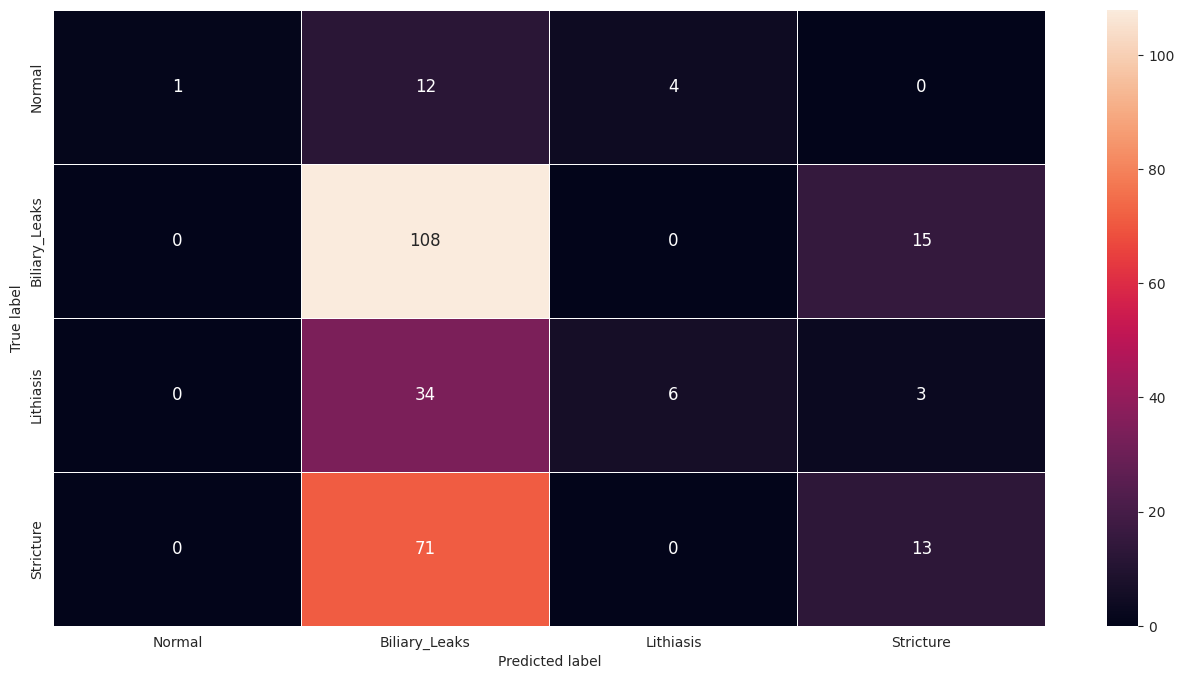

In [27]:
# Mudar o modelo para modo de avaliação
modelo_final_sota.eval()

# 1. Criar o loader de teste (usando o MedNISTDataset do teu projeto)[cite: 1]
dataset_teste = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms_avancadas)
test_loader = DataLoader(dataset_teste, batch_size=4, shuffle=False, num_workers=0)

# 2. Correr a avaliação
actual_values, predictions = evaluate_model(test_loader, modelo_final_sota)

print("\n" + "="*50 + "\nRELATÓRIO DE CLASSIFICAÇÃO DETALHADO:\n" + "="*50)
# Mostra Precision, Recall e F1-Score por classe
print(classification_report(actual_values, predictions, target_names=classes, digits=4, zero_division=0))

# 3. Gerar e gravar a nova Matriz de Confusão de Teste
cm_final = confusion_matrix(actual_values, predictions)
display_confusion_matrix(cm_final, classes, "efficientnet_b4_final")

In [28]:
# 1. CORREÇÃO CIRÚRGICA: Remover o 'alpha' (pesos manuais) para evitar a sobre-compensação
# Deixamos a Focal Loss trabalhar de forma limpa, igual à da Mónica[cite: 1]
criterio_focal_limpo = FocalLoss(to_onehot_y=True)

# 2. Reset do modelo para limpar o "vício" anterior
print("A reiniciar a EfficientNet-B4...")
modelo_sota = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)

for param in modelo_sota.parameters():
    param.requires_grad = False

num_ftrs = modelo_sota.classifier[1].in_features
modelo_sota.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(num_ftrs, num_class)
)
modelo_sota = modelo_sota.to(device)

# 3. Otimizador e Scheduler para as 5 épocas iniciais
otimizador_sota = torch.optim.AdamW(filter(lambda p: p.requires_grad, modelo_sota.parameters()), lr=1e-3, weight_decay=1e-2)
EPOCHS_CONGELADO = 5
scheduler_sota = CosineAnnealingLR(otimizador_sota, T_max=EPOCHS_CONGELADO)

# 4. Executar Fase 1 (Rápida)
print("A iniciar o treino rápido da camada final...")
modelo_sota_treinado = treinar_modelo_avancado(
    modelo_sota, dataloaders_avancados, criterio_focal_limpo, otimizador_sota, scheduler_sota, num_epocas=EPOCHS_CONGELADO, patience=3
)

A reiniciar a EfficientNet-B4...
A iniciar o treino rápido da camada final...

Época 1/5
----------


Treino Loss: 0.1409 Acc: 0.4470


Val Loss: 0.1452 Acc: 0.4145
** Novo melhor modelo guardado! (Loss: 0.1452) **

Época 2/5
----------


Treino Loss: 0.1384 Acc: 0.4424


Val Loss: 0.1382 Acc: 0.4188
** Novo melhor modelo guardado! (Loss: 0.1382) **

Época 3/5
----------


...

Val Loss: 0.1381 Acc: 0.4274
** Novo melhor modelo guardado! (Loss: 0.1381) **

Época 4/5
----------


Treino Loss: 0.1318 Acc: 0.4649


Val Loss: 0.1352 Acc: 0.4316
** Novo melhor modelo guardado! (Loss: 0.1352) **

Época 5/5
----------


Treino Loss: 0.1307 Acc: 0.4499


Val Loss: 0.1363 Acc: 0.4231

Treino completo em 5m 29s


In [30]:
# 1. DESCONGELAR TODAS AS CAMADAS
# Agora permitimos que o modelo ajuste os seus "olhos" aos teus raios-X
for param in modelo_sota_treinado.parameters():
    param.requires_grad = True

# 2. Configurar uma Learning Rate muito baixa para um ajuste fino e cirúrgico
FINE_TUNE_LR = 1e-5
EPOCHS_FINE_TUNE = 35

# Otimizador para TODAS as camadas com taxa de aprendizagem reduzida
otimizador_finetune = torch.optim.AdamW(modelo_sota_treinado.parameters(), lr=FINE_TUNE_LR, weight_decay=1e-2)
scheduler_finetune = CosineAnnealingLR(otimizador_finetune, T_max=EPOCHS_FINE_TUNE)

print("A iniciar o Fine-Tuning Profundo (Todas as camadas livres)...")

# 3. Arrancar com o treino definitivo
modelo_final_sota = treinar_modelo_avancado(
    modelo_sota_treinado, 
    dataloaders_avancados, 
    criterio_focal_limpo, 
    otimizador_finetune, 
    scheduler_finetune, 
    num_epocas=EPOCHS_FINE_TUNE,
    patience=7 # Se não melhorar em 7 épocas, para automaticamente
)

A iniciar o Fine-Tuning Profundo (Todas as camadas livres)...

Época 1/35
----------


Treino Loss: 0.1285 Acc: 0.4789


Val Loss: 0.1361 Acc: 0.4530
** Novo melhor modelo guardado! (Loss: 0.1361) **

Época 2/35
----------


Treino Loss: 0.1274 Acc: 0.4836


Val Loss: 0.1352 Acc: 0.4402
** Novo melhor modelo guardado! (Loss: 0.1352) **

Época 3/35
----------


...

Val Loss: 0.1333 Acc: 0.4359

Época 30/35
----------


Treino Loss: 0.1151 Acc: 0.5829


Val Loss: 0.1328 Acc: 0.4487

Época 31/35
----------


Treino Loss: 0.1135 Acc: 0.5839


Val Loss: 0.1341 Acc: 0.4402

[Early Stopping] Paragem antecipada!

Treino completo em 38m 20s


F1 Score: 0.2688

RELATÓRIO DE CLASSIFICAÇÃO FINAL (CORRIGIDO):
               precision    recall  f1-score   support

       Normal     0.0000    0.0000    0.0000        17
Biliary_Leaks     0.4839    0.8537    0.6176       123
    Lithiasis     0.3750    0.1395    0.2034        43
    Stricture     0.4412    0.1786    0.2542        84

     accuracy                         0.4719       267
    macro avg     0.3250    0.2929    0.2688       267
 weighted avg     0.4221    0.4719    0.3973       267



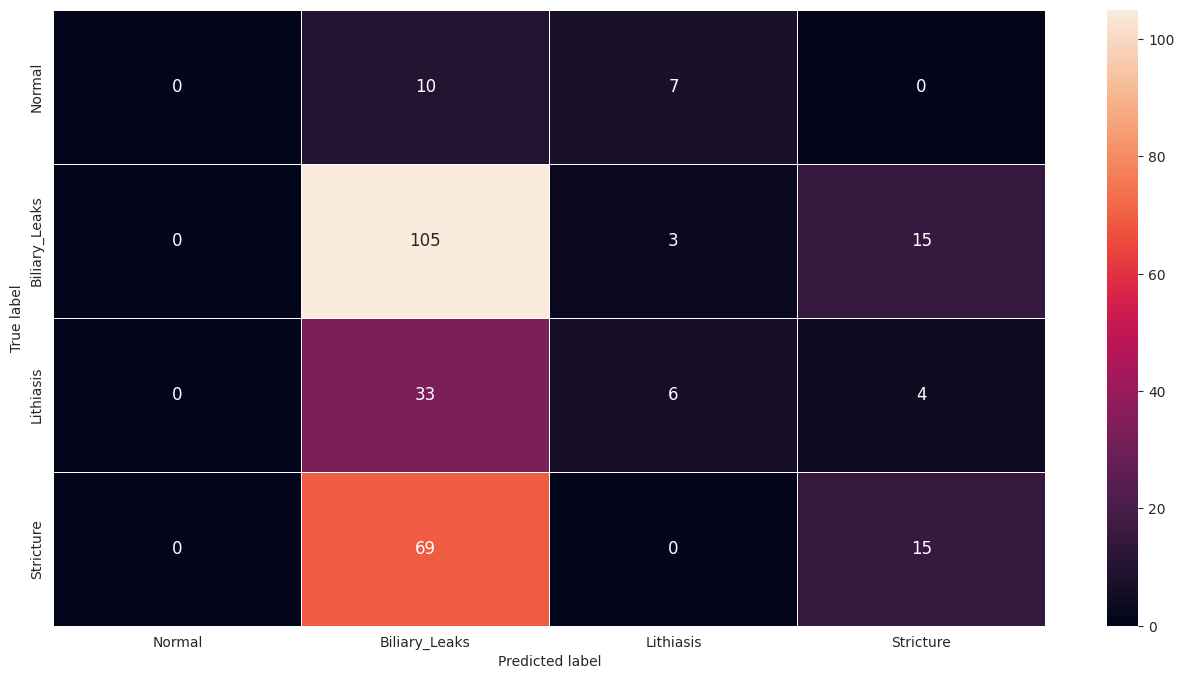

In [32]:
# Mudar o modelo para modo de avaliação
modelo_final_sota.eval()

# 1. Criar o loader de teste (usando o MedNISTDataset do teu projeto)[cite: 1]
dataset_teste = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms_avancadas)
test_loader = DataLoader(dataset_teste, batch_size=4, shuffle=False, num_workers=0)

# 2. Correr a avaliação usando as funções da baseline
actual_values, predictions = evaluate_model(test_loader, modelo_final_sota)

print("\n" + "="*50 + "\nRELATÓRIO DE CLASSIFICAÇÃO FINAL (CORRIGIDO):\n" + "="*50)
# Mostra Precision, Recall e F1-Score por classe
print(classification_report(actual_values, predictions, target_names=classes, digits=4, zero_division=0))

# 3. Gerar e gravar a nova Matriz de Confusão de Teste com Seaborn
cm_final = confusion_matrix(actual_values, predictions)
display_confusion_matrix(cm_final, classes, "efficientnet_b4_corrigido")

A reiniciar a ResNet50 com a pipeline corrigida...

Época 1/35
----------


Treino Loss: 0.1317 | F1-Macro: 0.2391


Val Loss: 0.1510 | F1-Macro: 0.1845
🌟 ** NOVO RECORDE DE F1 VALIDAÇÃO: 0.1845 (Modelo Guardado) **

Época 2/35
----------


Treino Loss: 0.1207 | F1-Macro: 0.3953


Val Loss: 0.1355 | F1-Macro: 0.2890
🌟 ** NOVO RECORDE DE F1 VALIDAÇÃO: 0.2890 (Modelo Guardado) **

Época 3/35
----------


...

Val Loss: 0.3186 | F1-Macro: 0.4138

Época 16/35
----------


Treino Loss: 0.0341 | F1-Macro: 0.9015


Val Loss: 0.2907 | F1-Macro: 0.4589

Época 17/35
----------


Treino Loss: 0.0283 | F1-Macro: 0.9257


Val Loss: 0.2561 | F1-Macro: 0.4382

[Early Stopping] O F1-Score estagnou. Paragem protetora na época 17!

Treino completo em 19m 53s

A INICIAR AVALIAÇÃO NO DATASET DE TESTE
F1 Score: 0.4802

RELATÓRIO DE CLASSIFICAÇÃO FINAL:
               precision    recall  f1-score   support

       Normal     0.4000    0.1176    0.1818        17
Biliary_Leaks     0.6307    0.9024    0.7425       123
    Lithiasis     0.6923    0.2093    0.3214        43
    Stricture     0.7260    0.6310    0.6752        84

     accuracy                         0.6554       267
    macro avg     0.6123    0.4651    0.4802       267
 weighted avg     0.6559    0.6554    0.6178       267



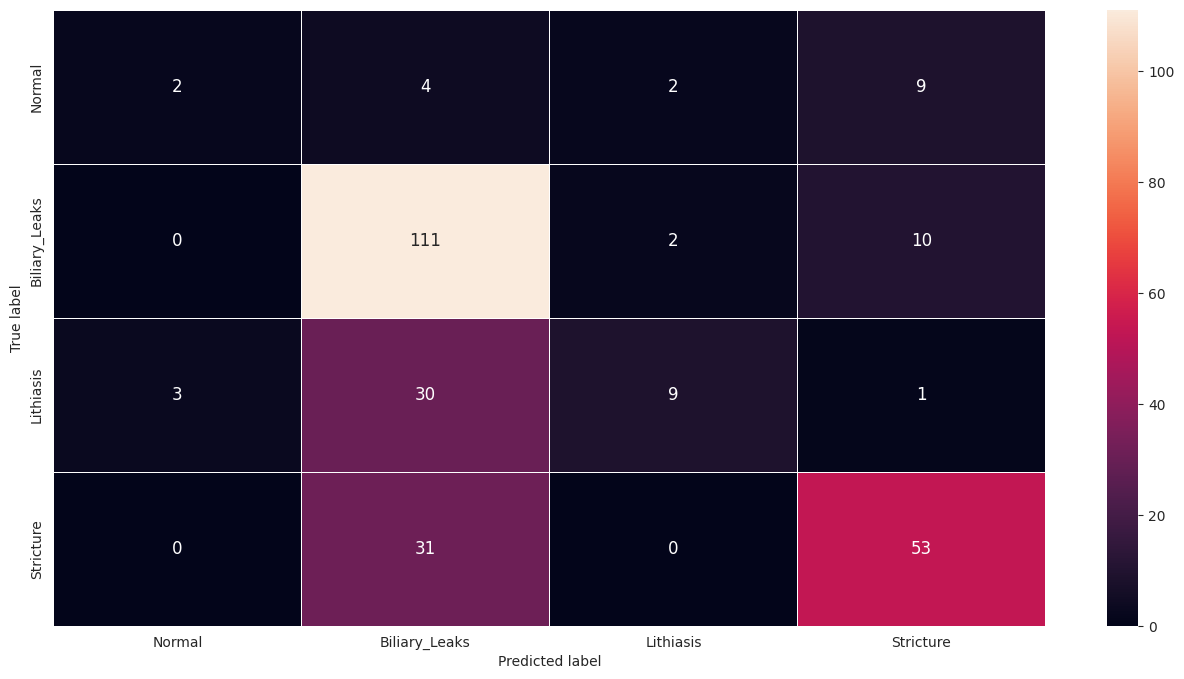

In [34]:
import torch
import torch.nn as nn
import time
import copy
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import torchvision.models as models
from torch.optim.lr_scheduler import CosineAnnealingLR

# ========================================================
# 1. FUNÇÃO DE TREINO CORRIGIDA (FOCO NO F1-SCORE MACRO)
# ========================================================
def treinar_modelo_focado_em_f1(modelo, dataloaders, criterio, otimizador, scheduler, num_epocas=35, patience=8):
    tempo_inicio = time.time()
    melhor_modelo_pesos = copy.deepcopy(modelo.state_dict())
    
    # MUDANÇA CRUCIAL: Rastrear o MELHOR F1-SCORE e não a menor Loss!
    melhor_f1_val = -1.0 
    epocas_sem_melhoria = 0
    
    for epoca in range(num_epocas):
        print(f'\nÉpoca {epoca+1}/{num_epocas}')
        print('-' * 10)

        for fase in ['treino', 'val']:
            if fase == 'treino':
                modelo.train()
            else:
                modelo.eval()

            loss_acumulada = 0.0
            todas_preds = []
            todas_labels = []

            loop = tqdm(dataloaders[fase], total=len(dataloaders[fase]), leave=False, desc=fase.capitalize())
            
            for imagens, labels in loop:
                imagens = imagens.to(device)
                labels = labels.to(device)

                otimizador.zero_grad()

                with torch.set_grad_enabled(fase == 'treino'):
                    saidas = modelo(imagens)
                    _, previsoes = torch.max(saidas, 1)
                    loss = criterio(saidas, labels)

                    if fase == 'treino':
                        loss.backward()
                        otimizador.step()

                loss_acumulada += loss.item() * imagens.size(0)
                todas_preds.extend(previsoes.cpu().numpy())
                todas_labels.extend(labels.cpu().numpy())
                loop.set_postfix(loss=loss.item())

            epoca_loss = loss_acumulada / len(dataloaders[fase].dataset)
            epoca_f1 = f1_score(todas_labels, todas_preds, average='macro', zero_division=0)

            print(f'{fase.capitalize()} Loss: {epoca_loss:.4f} | F1-Macro: {epoca_f1:.4f}')

            # A decisão de guardar o modelo baseia-se agora no F1-Score de Validação!
            if fase == 'val':
                if epoca_f1 > melhor_f1_val:
                    melhor_f1_val = epoca_f1
                    melhor_modelo_pesos = copy.deepcopy(modelo.state_dict())
                    epocas_sem_melhoria = 0
                    print(f"🌟 ** NOVO RECORDE DE F1 VALIDAÇÃO: {melhor_f1_val:.4f} (Modelo Guardado) **")
                else:
                    epocas_sem_melhoria += 1
                    
        scheduler.step()
        
        if epocas_sem_melhoria >= patience:
            print(f"\n[Early Stopping] O F1-Score estagnou. Paragem protetora na época {epoca+1}!")
            break

    tempo_decorrido = time.time() - tempo_inicio
    print(f'\nTreino completo em {tempo_decorrido // 60:.0f}m {tempo_decorrido % 60:.0f}s')

    # Carrega o cérebro que teve o maior F1-Score estável
    modelo.load_state_dict(melhor_modelo_pesos)
    return modelo


# ========================================================
# 2. CONFIGURAR A RESNET50 E OTIMIZADORES
# ========================================================
print("A reiniciar a ResNet50 com a pipeline corrigida...")
modelo_resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Descongelamos as camadas profundas para permitir aprendizagem real
for name, param in modelo_resnet.named_parameters():
    if "layer3" not in name and "layer4" not in name and "fc" not in name:
        param.requires_grad = False

num_ftrs = modelo_resnet.fc.in_features
modelo_resnet.fc = nn.Sequential(
    nn.Dropout(p=0.4), 
    nn.Linear(num_ftrs, num_class)
)
modelo_resnet = modelo_resnet.to(device)

criterio_focal_limpo = FocalLoss(to_onehot_y=True)
LEARNING_RATE = 2e-4
EPOCHS = 35

otimizador_resnet = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, modelo_resnet.parameters()), 
    lr=LEARNING_RATE, 
    weight_decay=0.03
)
scheduler_resnet = CosineAnnealingLR(otimizador_resnet, T_max=EPOCHS)


# ========================================================
# 3. ARRANCAR O TREINO E AVALIAÇÃO AUTOMÁTICA
# ========================================================
modelo_final_resnet = treinar_modelo_focado_em_f1(
    modelo_resnet, dataloaders_avancados, criterio_focal_limpo, otimizador_resnet, scheduler_resnet, num_epocas=EPOCHS, patience=8
)

print("\n" + "="*50 + "\nA INICIAR AVALIAÇÃO NO DATASET DE TESTE\n" + "="*50)
modelo_final_resnet.eval()

dataset_teste = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms_avancadas)
test_loader = DataLoader(dataset_teste, batch_size=4, shuffle=False, num_workers=0)

actual_values, predictions = evaluate_model(test_loader, modelo_final_resnet)

print("\n" + "="*50 + "\nRELATÓRIO DE CLASSIFICAÇÃO FINAL:\n" + "="*50)
print(classification_report(actual_values, predictions, target_names=classes, digits=4, zero_division=0))

cm_resnet = confusion_matrix(actual_values, predictions)
display_confusion_matrix(cm_resnet, classes, "resnet50_f1_opt")

A re-equilibrar o DataLoader com WeightedRandomSampler...
DataLoaders perfeitamente equilibrados!

🔥 A iniciar o treino com dados equilibrados por Sampler...

Época 1/35
----------


Treino Loss: 0.1391 | F1-Macro: 0.3656


Val Loss: 0.1449 | F1-Macro: 0.1916
🌟 ** NOVO RECORDE DE F1 VALIDAÇÃO: 0.1916 (Modelo Guardado) **

Época 2/35
----------


Treino Loss: 0.1166 | F1-Macro: 0.5366


Val Loss: 0.1562 | F1-Macro: 0.1722

Época 3/35
----------


...

Val Loss: 0.2340 | F1-Macro: 0.4701

Época 19/35
----------


Treino Loss: 0.0183 | F1-Macro: 0.9539


Val Loss: 0.1820 | F1-Macro: 0.4693

Época 20/35
----------


Treino Loss: 0.0215 | F1-Macro: 0.9459


Val Loss: 0.1993 | F1-Macro: 0.5168

[Early Stopping] O F1-Score estagnou. Paragem protetora na época 20!

Treino completo em 42m 49s

A INICIAR AVALIAÇÃO NO DATASET DE TESTE
F1 Score: 0.5881

RELATÓRIO DE CLASSIFICAÇÃO DEFINITIVO:
               precision    recall  f1-score   support

       Normal     0.4545    0.2941    0.3571        17
Biliary_Leaks     0.6800    0.8293    0.7473       123
    Lithiasis     0.5357    0.6977    0.6061        43
    Stricture     0.8600    0.5119    0.6418        84

     accuracy                         0.6742       267
    macro avg     0.6326    0.5832    0.5881       267
 weighted avg     0.6990    0.6742    0.6665       267



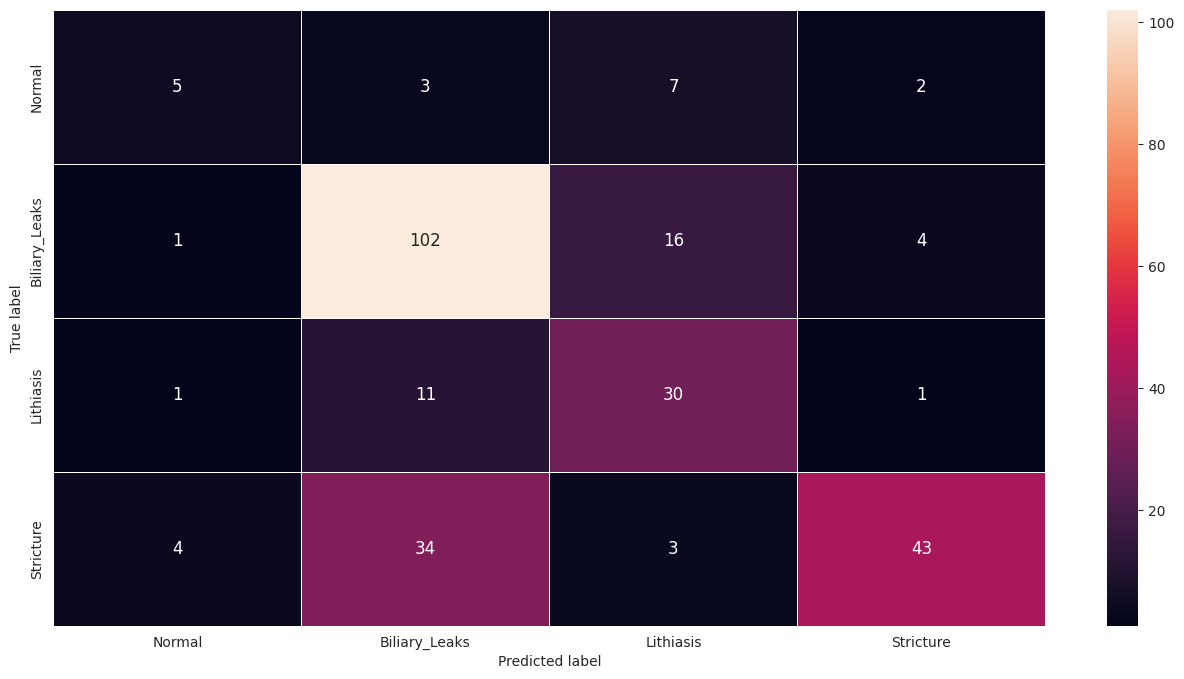

In [35]:
import torch
import torch.nn as nn
from torch.utils.data import WeightedRandomSampler, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.models as models

print("A re-equilibrar o DataLoader com WeightedRandomSampler...")

# 1. Calcular a frequência de cada classe no treino para criar os pesos
labels_treino = data['train']['labels']
contagem_classes = np.bincount(labels_treino)
pesos_classes = 1.0 / contagem_classes
pesos_amostras = np.array([pesos_classes[label] for label in labels_treino])

# O Sampler vai garantir que cada classe aparece de forma perfeitamente igual em cada batch!
sampler_equilibrado = WeightedRandomSampler(
    weights=torch.DoubleTensor(pesos_amostras),
    num_samples=len(pesos_amostras),
    replacement=True
)

# Recriar APENAS o DataLoader de treino com o Sampler (atenção: shuffle tem de ser False ao usar Sampler)
dataloader_treino_eq = DataLoader(dataset_treino, batch_size=4, sampler=sampler_equilibrado, num_workers=0)
dataloaders_avancados['treino'] = dataloader_treino_eq

print("DataLoaders perfeitamente equilibrados!")

# 2. RE-INICIALIZAR A RESNET50 PARA O COMBATE FINAL
modelo_resnet_final = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Descongelamos as camadas profundas para poderem aprender as nuances finas das classes raras
for name, param in modelo_resnet_final.named_parameters():
    if "layer3" not in name and "layer4" not in name and "fc" not in name:
        param.requires_grad = False

num_ftrs = modelo_resnet_final.fc.in_features
modelo_resnet_final.fc = nn.Sequential(
    nn.Dropout(p=0.4), 
    nn.Linear(num_ftrs, num_class)
)
modelo_resnet_final = modelo_resnet_final.to(device)

# Otimizador com boa regularização (Weight Decay)
otimizador_resnet = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, modelo_resnet_final.parameters()), 
    lr=2e-4, 
    weight_decay=0.03
)
scheduler_resnet = CosineAnnealingLR(otimizador_resnet, T_max=35)

# 3. ARRANCAR O TREINO EQUILIBRADO
print("\n🔥 A iniciar o treino com dados equilibrados por Sampler...")
modelo_sota_equilibrado = treinar_modelo_focado_em_f1(
    modelo_resnet_final, dataloaders_avancados, criterio_focal_limpo, otimizador_resnet, scheduler_resnet, num_epocas=35, patience=8
)

# ========================================================
# 4. AVALIAÇÃO AUTOMÁTICA FINAL
# ========================================================
print("\n" + "="*50 + "\nA INICIAR AVALIAÇÃO NO DATASET DE TESTE\n" + "="*50)
modelo_sota_equilibrado.eval()

actual_values, predictions = evaluate_model(test_loader, modelo_sota_equilibrado)

print("\n" + "="*50 + "\nRELATÓRIO DE CLASSIFICAÇÃO DEFINITIVO:\n" + "="*50)
print(classification_report(actual_values, predictions, target_names=classes, digits=4, zero_division=0))

cm_final = confusion_matrix(actual_values, predictions)
display_confusion_matrix(cm_final, classes, "resnet50_sampler_opt")